In [1]:
from scipy.stats import norm
import math
import numpy as np
from scipy.stats import norm
from scipy.stats import mvn
import scipy.stats as ss
import matplotlib.pyplot as plt

In [2]:
#https://github.com/fedemilanesio/Financial-Engineering/blob/main/Pricing_BAR_Cont.py.py

def BARRIER_CLOSED(params, option_type, barrier_type, barrier_level):
    S, K, T, sigma, r, q = params[0], params[1], params[2], params[3], params[4], params[5]
    b = r - q
    H = barrier_level * S
    rebate = 0
    option_type = option_type[0].upper()
    barrier_type = barrier_type.upper()


    if barrier_type in ["DO", "DI"] and S <= H:
        if barrier_type == "DO":
            return 0.0
        else:
            d1 = (np.log(S / K) + (b + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
            d2 = d1 - sigma * np.sqrt(T)
            if option_type == "C":
                return S * np.exp((b - r) * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
            else:
                return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp((b - r) * T) * norm.cdf(-d1)


    if barrier_type in ["UO", "UI"] and S >= H:
        if barrier_type == "UO":
            return 0.0  # L'opzione è morta, vale 0 assoluto.
        else: # UI
            # L'opzione è attivata. Diventa una Vanilla standard (Black-Scholes)
            d1 = (np.log(S / K) + (b + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
            d2 = d1 - sigma * np.sqrt(T)
            if option_type == "C":
                return S * np.exp((b - r) * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
            else:
                return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp((b - r) * T) * norm.cdf(-d1)

    # =========================================================================

    # Se l'opzione è viva e non ha ancora toccato la barriera,
    # procedo con le formule chiuse di Reiner e Rubinstein originali.
    match (option_type, barrier_type):
        case ("C", "DI"):
            eta, phi = 1, 1
        case ("C", "UI"):
            eta, phi = -1, 1
        case ("P", "UI"):
            eta, phi = -1, -1
        case ("P", "DI"):
            eta, phi = 1, -1
        case ("C", "DO"):
            eta, phi = 1, 1
        case ("C", "UO"):
            eta, phi = -1, 1
        case ("P", "UO"):
            eta, phi = -1, -1
        case ("P", "DO"):
            eta, phi = 1, -1
        case _:
            raise ValueError("Invalid Option or Barrier Type")

    mu = (b - sigma ** 2 / 2) / sigma ** 2
    x1 = np.log(S / K) / (sigma * np.sqrt(T)) + (1 + mu) * sigma * np.sqrt(T)
    x2 = np.log(S / H) / (sigma * np.sqrt(T)) + (1 + mu) * sigma * np.sqrt(T)
    y1 = np.log(H ** 2 / (S * K)) / (sigma * np.sqrt(T)) + (1 + mu) * sigma * np.sqrt(T)
    y2 = np.log(H / S) / (sigma * np.sqrt(T)) + (1 + mu) * sigma * np.sqrt(T)
    lam = np.sqrt(mu ** 2 + 2 * r / sigma ** 2)
    z = np.log(H / S) / (sigma * np.sqrt(T)) + lam * sigma * np.sqrt(T)

    A = phi * S * np.exp((b - r) * T) * norm.cdf(phi * x1) - phi * K * np.exp(-r * T) * norm.cdf(
        phi * x1 - phi * sigma * np.sqrt(T))
    B = phi * S * np.exp((b - r) * T) * norm.cdf(phi * x2) - phi * K * np.exp(-r * T) * norm.cdf(
        phi * x2 - phi * sigma * np.sqrt(T))
    C = phi * S * np.exp((b - r) * T) * (H / S) ** (2 * (mu + 1)) * norm.cdf(eta * y1) - phi * K * np.exp(-r * T) * (
                H / S) ** (2 * mu) * norm.cdf(eta * y1 - eta * sigma * np.sqrt(T))
    D = phi * S * np.exp((b - r) * T) * (H / S) ** (2 * (mu + 1)) * norm.cdf(eta * y2) - phi * K * np.exp(-r * T) * (
                H / S) ** (2 * mu) * norm.cdf(eta * y2 - eta * sigma * np.sqrt(T))
    E = rebate * np.exp(-r * T) * (norm.cdf(eta * x2 - eta * sigma * np.sqrt(T)) - ((H / S) ** (2 * mu)) * norm.cdf(
        eta * y2 - eta * sigma * np.sqrt(T)))
    F = rebate * ((H / S) ** (mu + lam) * norm.cdf(eta * z) + (H / S) ** (mu - lam) * norm.cdf(
        eta * z - 2 * eta * lam * sigma * np.sqrt(T)))

    value = 0
    # Qui avviene il check sullo Strike (K) rispetto alla Barriera (H)
    if (option_type == "C") and (barrier_type == "DI"):
        value = C + E if (K > H) else A - B + D + E
    if (option_type == "C") and (barrier_type == "UI"):
        value = A + E if (K > H) else B - C + D + E
    if (option_type == "P") and (barrier_type == "DI"):
        value = B - C + D + E if (K > H) else A + E
    if (option_type == "P") and (barrier_type == "UI"):
        value = A - B + D + E if (K > H) else C + E
    if (option_type == "C") and (barrier_type == "DO"):
        value = A - C + F if (K > H) else B - D + F
    if (option_type == "C") and (barrier_type == "UO"):
        value = F if (K > H) else A - B + C - D + F
    if (option_type == "P") and (barrier_type == "DO"):
        value = A - B + C - D + F if (K > H) else F
    if (option_type == "P") and (barrier_type == "UO"):
        value = B - D + F if (K > H) else A - C + F

    return value

In [3]:
## https://github.com/YuChenAmberLu?tab=repositories

## Adapted for Dividends

## import certain packages

from math import log, sqrt, pi, exp

from scipy.stats import norm



#import numpy as np

#import pandas as pd

from pandas import DataFrame



# Underlying price (per share): S;

# Strike price of the option (per share): K;

# Time to maturity (years): T;

# Continuously compounding risk-free interest rate: r;

# Continuously compounding dividend: q;

# Volatility: sigma;



## define two functions, d1 and d2 in Black-Scholes model

def d1(S,K,T,r,q,sigma):

# change sigma*sqrt(T) to (sigma*sqrt(T))

    return(log(S/K)+(r - q +sigma**2/2.)*T)/(sigma*sqrt(T))

def d2(S,K,T,r,q,sigma):

    return d1(S,K,T,r,q,sigma)-sigma*sqrt(T)





## define the call options price function

def bs_call(S,K,T,r,q,sigma):

    return S*exp(-q*T)*norm.cdf(d1(S,K,T,r,q,sigma))-K*exp(-r*T)*norm.cdf(d2(S,K,T,r,q,sigma))



## define the put options price function

def bs_put(S,K,T,r,q,sigma):

    return K*exp(-r*T)-S*exp(-q*T)+bs_call(S,K,T,r,q,sigma)



In [4]:
# Parametri di esempio
S0 = 100      # Prezzo attuale
K = 100       # Strike
T = 1         # 1 anno
r = 0.05      # Tasso
sigma = 0.2   # Volatilità
q = 0
L = 0.90        # Barriera
input_params = [S0, K, T, sigma, r, q]


prezzobarrier = BARRIER_CLOSED(input_params, "C", "DO", L)
prezzobarrier2 = BARRIER_CLOSED(input_params, "C", "DI", L)

prezzoblack = bs_call(S0, K, T, r,q, sigma)

print(f"Il prezzo dell'opzione Down-and-Out Call (Chiusa): {prezzobarrier:.4f}")
print(f"Il prezzo dell'opzione Down-and-In Call (Chiusa): {prezzobarrier2:.4f}")
print(f"Il prezzo dell'opzione Black-Scholes (senza barriera): {prezzoblack:.4f}")

if abs((prezzobarrier + prezzobarrier2) - prezzoblack) ==0:
    print("Verifica In-Out Parity: Successo (Somma uguale a BS standard)")
    print("The software house must have used the formula with the vanilla option")
else:
    print("Verifica In-Out Parity: Fallimento (Somma non uguale a BS standard)")




Il prezzo dell'opzione Down-and-Out Call (Chiusa): 8.6655
Il prezzo dell'opzione Down-and-In Call (Chiusa): 1.7851
Il prezzo dell'opzione Black-Scholes (senza barriera): 10.4506
Verifica In-Out Parity: Successo (Somma uguale a BS standard)
The software house must have used the formula with the vanilla option


#Part 2


In [5]:
# Parametri di esempio
S0 = 100      # Prezzo attuale
K = 100       # Strike
T = 1         # 1 anno
r = 0.05      # Tasso
sigma = 0.2   # Volatilità
q = 0

barrier_levels = []
prices_do = []
prices_di = []

for i in range(50,100,7):
    L = i/S0       # Barriera
    input_params = [S0, K, T, sigma, r, q]


    prezzobarrier = BARRIER_CLOSED(input_params, "C", "DO", L)
    prezzobarrier2 = BARRIER_CLOSED(input_params, "C", "DI", L)

    barrier_levels.append(L)
    prices_do.append(prezzobarrier)
    prices_di.append(prezzobarrier2)

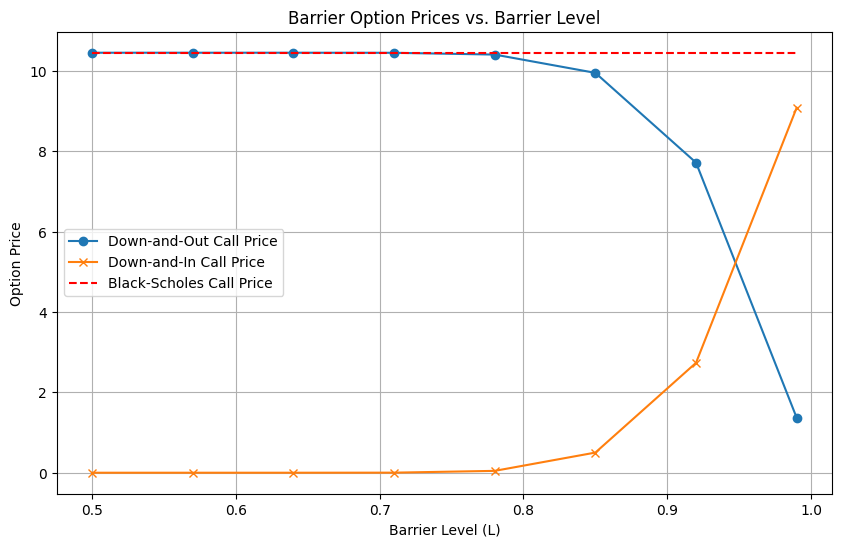

In [6]:


# Assuming prezzoblack is already calculated and available from previous cells
# We need to create a list of prezzoblack values to plot it against barrier_levels
bs_prices = [prezzoblack] * len(barrier_levels)

plt.figure(figsize=(10, 6))
plt.plot(barrier_levels, prices_do, label='Down-and-Out Call Price', marker='o')
plt.plot(barrier_levels, prices_di, label='Down-and-In Call Price', marker='x')
plt.plot(barrier_levels, bs_prices, label='Black-Scholes Call Price', linestyle='--', color='red')
plt.xlabel('Barrier Level (L)')
plt.ylabel('Option Price')
plt.title('Barrier Option Prices vs. Barrier Level')
plt.grid(True)
plt.legend()
plt.show()

clearly the lower the barrier the more difficult is to reach it and thus the down and out is worth lelss than the DI

--- CONVERGENZA PER L -> 0 ---
L=90.00 | DO Price=8.665472 | Err from Vanilla=1.79e+00
L=85.00 | DO Price=9.949270 | Err from Vanilla=5.01e-01
L=80.00 | DO Price=10.351345 | Err from Vanilla=9.92e-02
L=75.00 | DO Price=10.437870 | Err from Vanilla=1.27e-02
L=70.00 | DO Price=10.449633 | Err from Vanilla=9.51e-04
L=65.00 | DO Price=10.450547 | Err from Vanilla=3.65e-05
L=60.00 | DO Price=10.450583 | Err from Vanilla=6.13e-07
L=55.00 | DO Price=10.450584 | Err from Vanilla=3.65e-09
L=50.00 | DO Price=10.450584 | Err from Vanilla=5.83e-12
L=45.00 | DO Price=10.450584 | Err from Vanilla=1.78e-15
L=40.00 | DO Price=10.450584 | Err from Vanilla=0.00e+00
Rate of convergence (Alpha) for L->0: ~49.06


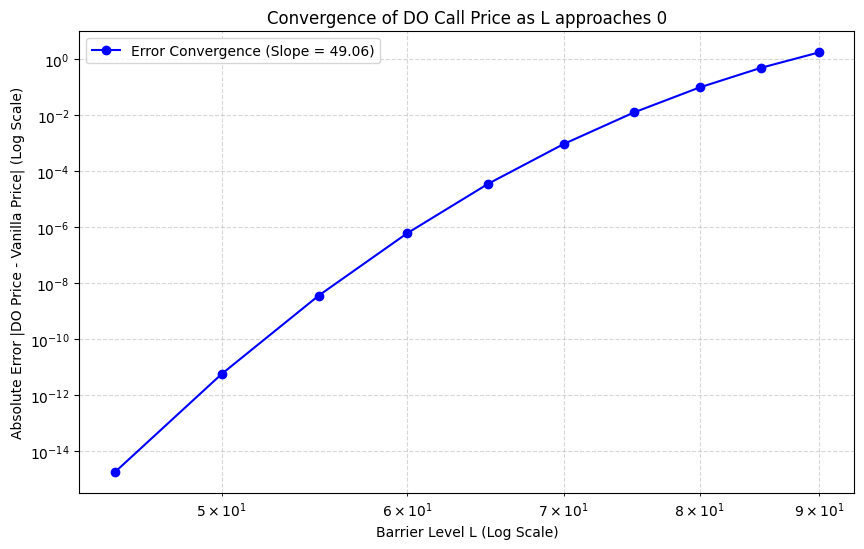


--- CONVERGENZA PER L -> S0 ---
L=96.00 | DO Price=4.740691
L=97.00 | DO Price=3.733918
L=98.00 | DO Price=2.610928
L=98.50 | DO Price=2.004488
L=99.00 | DO Price=1.367455
L=99.50 | DO Price=0.699414
L=99.90 | DO Price=0.142409
Rate of convergence (Beta) for L->S0: ~0.95


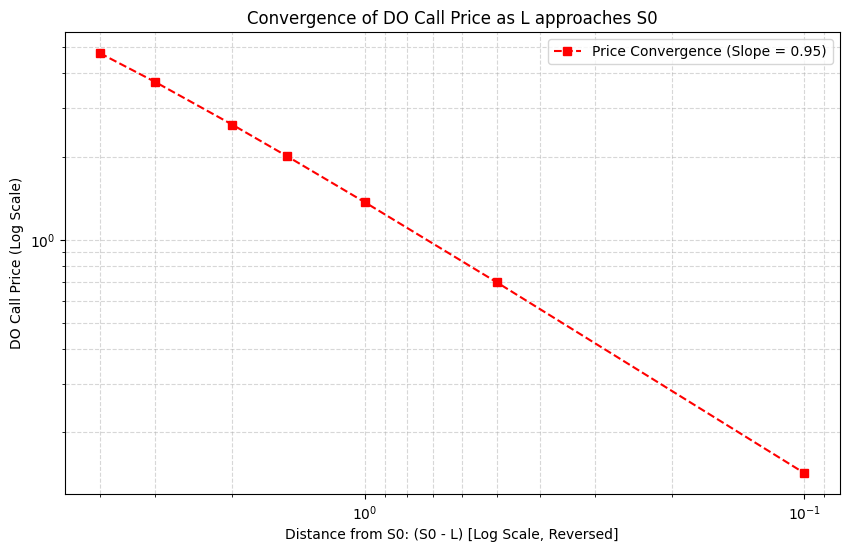

In [7]:

from scipy.stats import linregress

def DO_Call(S, K, T, sigma, r, q, L):
    params = [S, K, T, sigma, r, q]
    barrier_percentage = L /S
    return BARRIER_CLOSED(params, "C", "DO", barrier_percentage)

print("--- CONVERGENZA PER L -> 0 ---")

vanilla_price = bs_call(S0, K, T, r, q, sigma)
# Usiamo valori che permettono di vedere la curva prima del "Muro" dello zero assoluto
L_small = np.array([90.0, 85.0, 80.0, 75.0, 70.0,65, 60.0,55, 50.0,45, 40.0])
errors_0 = []

for L in L_small:
    price = DO_Call(S0, K, T, sigma, r, q, L)
    err = abs(vanilla_price - price)
    errors_0.append(err)
    print(f"L={L:5.2f} | DO Price={price:.6f} | Err from Vanilla={err:.2e}")

# FILTRO FONDAMENTALE: Prendo solo gli errori > 1e-15 per evitare il log(0)
valid_idx = [i for i, e in enumerate(errors_0) if e > 1e-15]
valid_L = L_small[valid_idx]
valid_err = np.array(errors_0)[valid_idx]

slope_0 = 0
if len(valid_idx) > 1:
    slope_0, _, _, _, _ = linregress(np.log(valid_L), np.log(valid_err))
    print(f"Rate of convergence (Alpha) for L->0: ~{slope_0:.2f}")

# Plot for L -> 0 convergence
plt.figure(figsize=(10, 6))
plt.loglog(valid_L, valid_err, marker='o', linestyle='-', color='blue',
           label=f'Error Convergence (Slope = {slope_0:.2f})')
plt.xlabel('Barrier Level L (Log Scale)')
plt.ylabel('Absolute Error |DO Price - Vanilla Price| (Log Scale)')
plt.title('Convergence of DO Call Price as L approaches 0')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()


print("\n--- CONVERGENZA PER L -> S0 ---")
# Ci avviciniamo a S0 (100) in modo logaritmico
L_large = np.array([96,97, 98.0,98.5, 99.0, 99.5, 99.9])
prices_S0 = []

for L in L_large:
    price = DO_Call(S0, K, T, sigma, r, q, L)
    prices_S0.append(price)
    print(f"L={L:5.2f} | DO Price={price:.6f}")

distanza_S0 = S0 - L_large

# Rate of convergence L->S0 (Regressione Log-Log)
slope_S0, _, _, _, _ = linregress(np.log(distanza_S0), np.log(prices_S0))
print(f"Rate of convergence (Beta) for L->S0: ~{slope_S0:.2f}")

# Plot for L -> S0 convergence
plt.figure(figsize=(10, 6))
plt.loglog(distanza_S0, prices_S0, marker='s', linestyle='--', color='red',
           label=f'Price Convergence (Slope = {slope_S0:.2f})')
# Invertiamo l'asse X per mostrare che ci stiamo "avvicinando" a zero distanza (cioè L -> S0)
plt.gca().invert_xaxis()
plt.xlabel('Distance from S0: (S0 - L) [Log Scale, Reversed]')
plt.ylabel('DO Call Price (Log Scale)')
plt.title('Convergence of DO Call Price as L approaches S0')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

comment on the financial interpretation

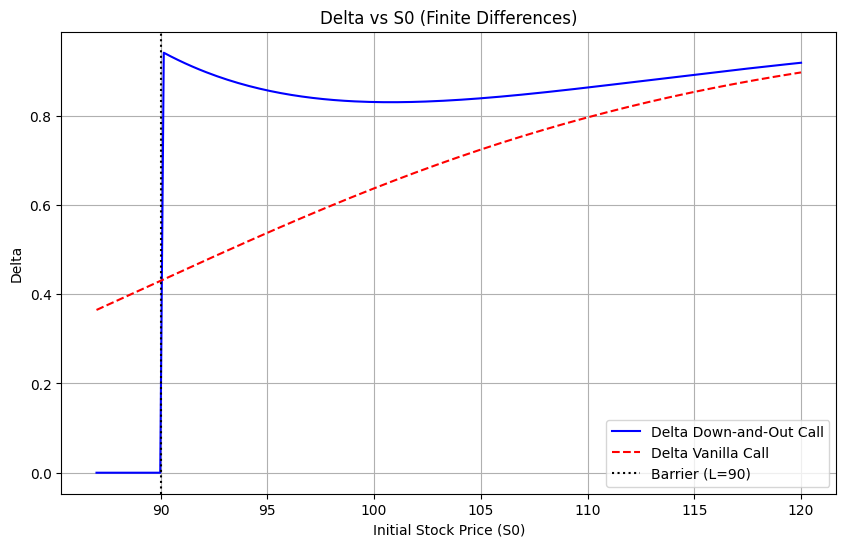

In [8]:
# ==============================================================================
# PARTE 2.3 & 2.4 & 3: Delta Finite Differences & Near the Barrier
# ==============================================================================
epsilon = 1e-5
L_fixed = 90

S_values = np.linspace(87, 120.0, 200)
delta_DO = []
delta_Vanilla = []

for S in S_values:
    V_V_up = bs_call(S + epsilon, K, T, r, q, sigma)
    V_V_dw = bs_call(S - epsilon, K, T, r, q, sigma)
    d_vanilla = (V_V_up - V_V_dw) / (2 * epsilon)
    delta_Vanilla.append(d_vanilla)

    # Delta Down-and-Out finite differences
    V_DO_up = DO_Call(S + epsilon, K, T, sigma, r, q, L_fixed)
    V_DO_dw = DO_Call(S - epsilon, K, T, sigma, r, q, L_fixed)
    d_do = (V_DO_up - V_DO_dw) / (2 * epsilon)
    delta_DO.append(d_do)


# --- PLOT DELTA (Punto 2.3 e 2.4) ---
plt.figure(figsize=(10, 6))
plt.plot(S_values, delta_DO, label='Delta Down-and-Out Call', color='blue')
plt.plot(S_values, delta_Vanilla, label='Delta Vanilla Call', color='red', linestyle='--')
plt.axvline(L_fixed, color='black', linestyle=':', label=f'Barrier (L={L_fixed})')
plt.title("Delta vs S0 (Finite Differences)")
plt.xlabel("Initial Stock Price (S0)")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()


#Part 3


--- GENERAZIONE GRAFICO PUNTO 3: NEAR THE BARRIER ---


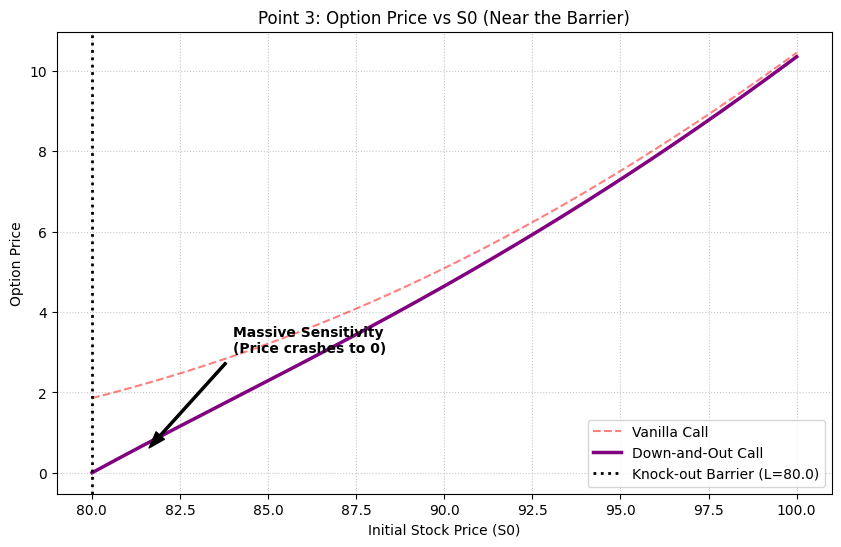

In [9]:


print("\n--- GENERAZIONE GRAFICO PUNTO 3: NEAR THE BARRIER ---")

L_fixed = 80.0
# Creiamo un array ad altissima risoluzione (500 punti) molto vicino alla barriera
S_near = np.linspace(80.01, 100.0, 500)
prices_DO_near = []
prices_Vanilla_near = []

for S in S_near:
    # Assicuratevi che bs_call e DO_Call siano definite come nello script precedente
    prices_DO_near.append(DO_Call(S, K, T, sigma, r, q, L_fixed))
    prices_Vanilla_near.append(bs_call(S, K, T, r, q, sigma))

plt.figure(figsize=(10, 6))

# Plottiamo la Vanilla come riferimento (tratteggiata)
plt.plot(S_near, prices_Vanilla_near, label='Vanilla Call', color='red', linestyle='--', alpha=0.5)

# Plottiamo la Down-and-Out
plt.plot(S_near, prices_DO_near, label='Down-and-Out Call', color='purple', linewidth=2.5)


plt.axvline(L_fixed, color='black', linestyle=':', linewidth=2, label=f'Knock-out Barrier (L={L_fixed})')


plt.annotate('Massive Sensitivity\n(Price crashes to 0)',
             xy=(81.5, 0.5), xytext=(84, 3),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, fontweight='bold')

plt.title("Point 3: Option Price vs S0 (Near the Barrier)")
plt.xlabel("Initial Stock Price (S0)")
plt.ylabel("Option Price")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

comment on the implication for hedging

#Part 4 - Monte Carlo

In [10]:
def MC_BARRIER_DO(N, intervals, S, K, Barrier_level, T, r, q, vol, flag):
    H = Barrier_level * S
    b = r - q
    dt = T / intervals
    discount = np.exp(-r * T)

    # 1. Inizializzo la matrice
    underlying_evolution_ITO = np.zeros((intervals + 1, N)) # Changed to intervals + 1 rows
    underlying_evolution_ITO[0, :] = S # Initialize the first row with the starting stock price

    # 2. Generazione delle traiettorie (vettorizzata)
    for i in range(1, intervals+1):
        # NOTA: np.random.standard_normal(N) è molto più veloce di norm.ppf(np.random.rand(N))
        Z = np.random.standard_normal(N)
        underlying_evolution_ITO[i, :] = underlying_evolution_ITO[i-1, :] * np.exp((b - (vol**2)/2)*dt + vol * Z * np.sqrt(dt))

    # 3. Controllo della Barriera (Vettorizzato: niente loop for!)
    # np.min(..., axis=0) trova il prezzo minimo raggiunto in OGNI colonna (traiettoria)
    # Se il minimo è < H, knocked_out diventa True (1), altrimenti False (0)
    knocked_out = (np.min(underlying_evolution_ITO, axis=0) <= H).astype(int)

    # Per una Down-and-Out, il flag di sopravvivenza è l'opposto!
    survived = 1 - knocked_out

    # 4. Calcolo del Payoff
    if flag.upper().startswith("C"):
        payoff = np.maximum(0, underlying_evolution_ITO[-1, :] - K)
    else:
        payoff = np.maximum(0, K - underlying_evolution_ITO[-1, :])

    # Moltiplico per 'survived' (se è morta, 0 * payoff = 0)
    discounted_payoff = discount * payoff * survived

    option_price_MC = np.mean(discounted_payoff)
    return option_price_MC

S0 = 100      # Prezzo attuale
K = 100       # Strike
T = 1         # 1 anno
r = 0.05      # Tasso
sigma = 0.2   # Volatilità
q = 0
L = 0.90        # Barriera
input_params = [S0, K, T, sigma, r, q]
N = [i for i in range (500, 10000, 500)]
num_intervals = [i for i in range (1,257,16)]  # Numero di step (intero)
prezzobarrier = BARRIER_CLOSED(input_params, "C", "DO", L)
prices = np.zeros((len(N),len(num_intervals)))
i=0
j=0

for f in N:
    for g in num_intervals:
      prezzoMC = MC_BARRIER_DO(f,g,S0,K,L,T,r,q,sigma,'C')
      prices[i,j]=prezzoMC
      j+=1
    j=0
    i+=1
print(f"Il prezzo dell'opzione Down-and-Out Call (Chiusa): {prezzobarrier:.4f}")
print(f"Il prezzo dell'opzione Down-and-Out Call (Monte Carlo): {prezzoMC:.4f}")

Il prezzo dell'opzione Down-and-Out Call (Chiusa): 8.6655
Il prezzo dell'opzione Down-and-Out Call (Monte Carlo): 8.6776


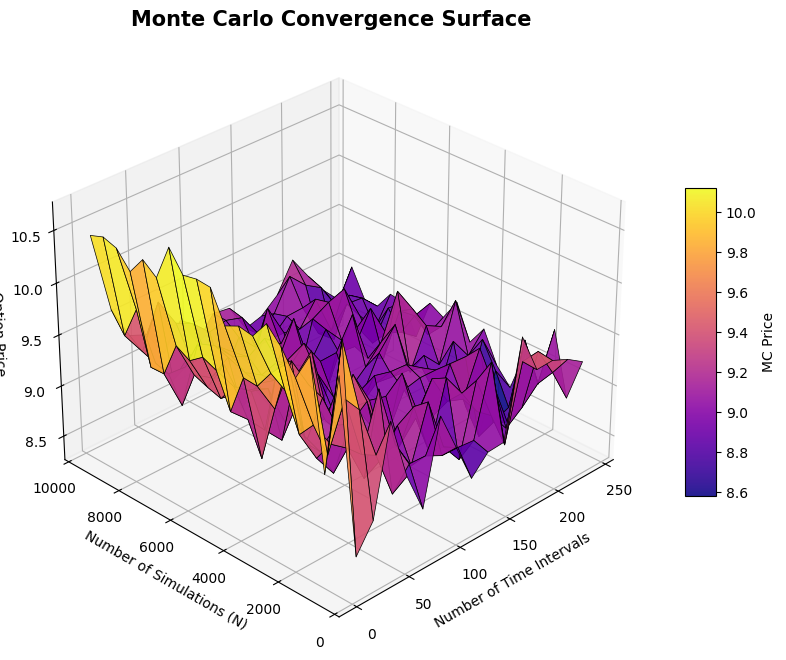

In [11]:
X, Y = np.meshgrid(num_intervals, N)

# =========================================================
# 3. PLOT DELLA SUPERFICIE 3D
# =========================================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Disegniamo la superficie.
# 'plasma' o 'viridis' sono ottime. edgecolor='k' disegna la griglia nera per far capire la scala.
surf = ax.plot_surface(X, Y, prices, cmap='plasma', edgecolor='k', linewidth=0.5, alpha=0.9)

# Etichette (Fondamentali per il report)
ax.set_title("Monte Carlo Convergence Surface", fontsize=15, fontweight='bold')
ax.set_xlabel("Number of Time Intervals")
ax.set_ylabel("Number of Simulations (N)")
ax.set_zlabel("Option Price")

# Barra dei colori laterale
fig.colorbar(surf, shrink=0.5, aspect=10, label="MC Price")

# Rotazione della telecamera:
# elev=30 (altezza), azim=-135 (ruotato per vedere bene l'angolo di convergenza)
ax.view_init(elev=30, azim=-135)

plt.show()

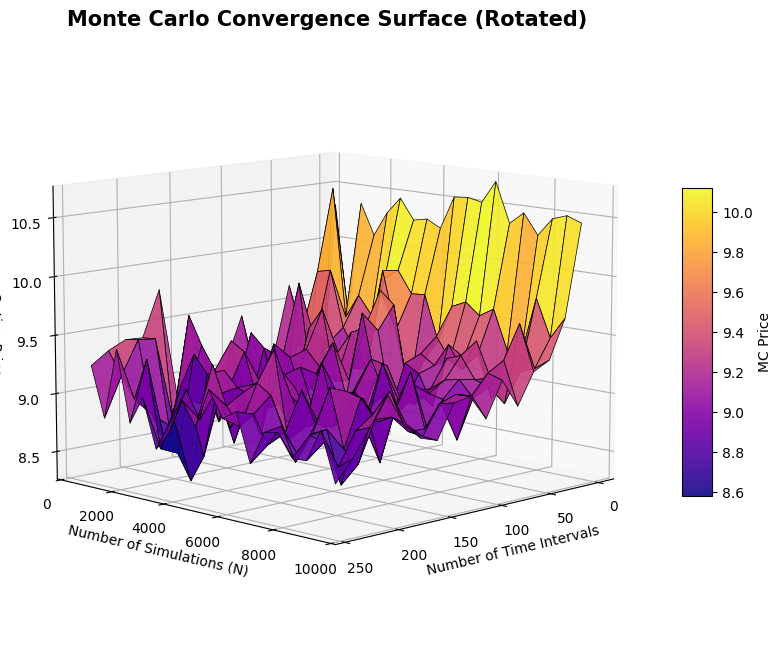

In [12]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, prices, cmap='plasma', edgecolor='k', linewidth=0.5, alpha=0.9)

ax.set_title("Monte Carlo Convergence Surface (Rotated)", fontsize=15, fontweight='bold')
ax.set_xlabel("Number of Time Intervals")
ax.set_ylabel("Number of Simulations (N)")
ax.set_zlabel("Option Price")

fig.colorbar(surf, shrink=0.5, aspect=10, label="MC Price")

# Modifica questi valori per ruotare il grafico
# elev: angolo di elevazione (verticale)
# azim: angolo azimutale (orizzontale)
ax.view_init(elev=10, azim=45) # Esempio di nuovi angoli

plt.show()

#Part 5

In [13]:
import numpy as np
import scipy.stats as si
from typing import Optional

class DownAndOutCallPricer:
    """
    Motore computazionale per opzioni a barriera Down-and-Out Call (DOC).
    Implementa il pricing analitico a tempo continuo (modello Reiner-Rubinstein 1991),
    il calcolo del parametro Vega tramite approssimazione differenziale centrale
    e l'inversione asintotica della Volatilità Implicita (IV).
    """

    def __init__(self, spot: float, strike: float, barrier: float,
                 maturity: float, rate: float, div_yield: float):
        """
        Costruttore dell'ecosistema di mercato e validazione term-sheet.
        """
        # Protezione vitale preventiva: l'opzione Knock-Out perde fondamento
        # ontologico se lo spot è strutturalmente nato invalido.
        if spot <= barrier:
            raise ValueError(f"Incongruenza Strutturale: Spot ({spot}) "
                             f"minore o uguale alla Barriera ({barrier}). Contratto Estinto.")
        if maturity <= 0.0:
            raise ValueError("Tempo a scadenza deve essere strettamente positivo.")

        self.S = spot
        self.K = strike
        self.H = barrier
        self.T = maturity
        self.r = rate
        self.q = div_yield

    def _black_scholes_call(self, sigma: float) -> float:
        """
        Sub-modulo per il pricing dell'equivalente Call Vanilla.
        Necessario per processare il ramo In-Out Parity.
        """
        d1 = (np.log(self.S / self.K) + (self.r - self.q + 0.5 * sigma**2) * self.T) / (sigma * np.sqrt(self.T))
        d2 = d1 - sigma * np.sqrt(self.T)

        return self.S * np.exp(-self.q * self.T) * si.norm.cdf(d1) \
               - self.K * np.exp(-self.r * self.T) * si.norm.cdf(d2)

    def calculate_price(self, sigma: float) -> float:
        """
        Risolutore analitico chiuso per l'opzione Down-and-Out Call.
        Biforca l'integrazione probabilistica in base al dislocamento spaziale K e H.
        """
        # Sicurezza: la volatilità nulla azzera la varianza stocastica
        if sigma <= 1e-8:
            return max(self.S - self.K, 0.0) * np.exp(-self.r * self.T)

        vol_T = sigma * np.sqrt(self.T)
        lambda_param = (self.r - self.q + 0.5 * sigma**2) / (sigma**2)

        # Caso 1: Strike posizionato sopra la Barriera.
        # Applica l'equivalenza lineare C_DOC = C_Vanilla - C_Down_and_In
        if self.K >= self.H:
            y = np.log((self.H**2) / (self.S * self.K)) / vol_T + lambda_param * vol_T

            c_di = self.S * np.exp(-self.q * self.T) * (self.H / self.S)**(2 * lambda_param) * si.norm.cdf(y) \
                 - self.K * np.exp(-self.r * self.T) * (self.H / self.S)**(2 * lambda_param - 2) * si.norm.cdf(y - vol_T)

            c_vanilla = self._black_scholes_call(sigma)
            price_do = c_vanilla - c_di

        # Caso 2: Strike inferiore alla Barriera.
        # Richiede estensione integrale per tranciatura delle path estinte.
        else:
            x1 = np.log(self.S / self.H) / vol_T + lambda_param * vol_T
            y1 = np.log(self.H / self.S) / vol_T + lambda_param * vol_T

            t1 = self.S * np.exp(-self.q * self.T) * si.norm.cdf(x1)
            t2 = self.K * np.exp(-self.r * self.T) * si.norm.cdf(x1 - vol_T)
            t3 = self.S * np.exp(-self.q * self.T) * (self.H / self.S)**(2 * lambda_param) * si.norm.cdf(y1)
            t4 = self.K * np.exp(-self.r * self.T) * (self.H / self.S)**(2 * lambda_param - 2) * si.norm.cdf(y1 - vol_T)

            price_do = t1 - t2 - t3 + t4

        # Ritorna valore smussato per sopprimere l'underflow dei float estremi
        return max(price_do, 0.0)

    def calculate_vega_fdm(self, sigma: float, eps: float = 1e-4) -> float:
        """
        Derivazione differenziale del Vega ricorrendo allo schema numerico a Differenza Finita Centrale.
        Garantisce resilienza di fronte a gradienti complessi e volatilità esotiche.
        """
        p_up = self.calculate_price(sigma + eps)
        p_down = self.calculate_price(sigma - eps)
        return (p_up - p_down) / (2 * eps)

    def iv_bisection(self, target_price: float,
                     sigma_min: float = 0.01, sigma_max: float = 3.0,
                     tolerance: float = 1e-6, max_iterations: int = 100) -> float:
        """
        Reverse-engineering robusto e privo di devianze tramite Metodo della Bisezione.
        Il sistema accerchia l'incognita ignorando anomalie di pendenza locale.
        """
        err_low = self.calculate_price(sigma_min) - target_price
        err_high = self.calculate_price(sigma_max) - target_price

        # Validazione del bracketing radiale.
        if err_low * err_high > 0:
            raise ValueError(f"Fallimento Bracketing in Bisezione: Impossibile "
                             f"garantire intersezione radicolare nel limite {sigma_min}-{sigma_max}.")

        for step in range(max_iterations):
            sigma_mid = 0.5 * (sigma_min + sigma_max)
            err_mid = self.calculate_price(sigma_mid) - target_price

            if abs(err_mid) < tolerance or (sigma_max - sigma_min) < tolerance:
                return sigma_mid

            if err_low * err_mid < 0:
                sigma_max = sigma_mid
                err_high = err_mid
            else:
                sigma_min = sigma_mid
                err_low = err_mid

        raise RuntimeError("Bisezione esausta: raggiungimento del limite di iterazioni senza tolleranza.")

    def iv_bisection_MC(self, target_price: float,
                     sigma_min: float = 0.01, sigma_max: float = 3.0,
                     tolerance: float = 1e-6, max_iterations: int = 100,
                     N_mc: int = 10000, intervals_mc: int = 252) -> float:
        """
        Reverse-engineering robusto e privo di devianze tramite Metodo della Bisezione.
        Il sistema accerchia l'incognita ignorando anomalie di pendenza locale.
        Questo metodo utilizza la funzione Monte Carlo per il pricing dell'opzione barriera.
        """
        # Definizione di una funzione helper per il pricing Monte Carlo
        # Assumiamo che MC_BARRIER_DO sia disponibile nello scope globale o sia importato.
        def mc_price_calculator(sigma_val):
            # MC_BARRIER_DO si aspetta Barrier_level come rapporto (H/S)
            return MC_BARRIER_DO(N=N_mc, intervals=intervals_mc, S=self.S, K=self.K,
                                 Barrier_level=self.H/self.S, T=self.T, r=self.r, q=self.q,
                                 vol=sigma_val, flag='C') # 'C' for Call option

        err_low = mc_price_calculator(sigma_min) - target_price
        err_high = mc_price_calculator(sigma_max) - target_price

        # Validazione del bracketing radiale.
        if err_low * err_high > 0:
            raise ValueError(f"Fallimento Bracketing in Bisezione: Impossibile "
                             f"garantire intersezione radicolare nel limite {sigma_min}-{sigma_max}. "
                             f"err_low={err_low:.4f}, err_high={err_high:.4f}.")

        for step in range(max_iterations):
            sigma_mid = 0.5 * (sigma_min + sigma_max)
            err_mid = mc_price_calculator(sigma_mid) - target_price

            if abs(err_mid) < tolerance or (sigma_max - sigma_min) < tolerance:
                return sigma_mid

            if err_low * err_mid < 0:
                sigma_max = sigma_mid
                err_high = err_mid
            else:
                sigma_min = sigma_mid
                err_low = err_mid

        raise RuntimeError("Bisezione esausta: raggiungimento del limite di iterazioni senza tolleranza.")


In [14]:
# Parameters for the Down-and-Out Call option
spot = 100.0
strike = 100.0
barrier = 90.0
maturity = 1.0
rate = 0.05
div_yield = 0.0

# Market observed price for which we want to find the implied volatility
market_obs_price = 8.66 # A price consistent with the analytical DO price for sigma=0.2

try:
    # Initialize the pricer
    doc_pricer = DownAndOutCallPricer(spot, strike, barrier, maturity, rate, div_yield)

    print(f"\n--- Calculating Implied Volatility for Down-and-Out Call (Target Price: {market_obs_price:.4f}) ---")

    # Calculate Implied Volatility using the Bisection Method
    implied_vol = doc_pricer.iv_bisection(target_price=market_obs_price)
    print(f"Implied Volatility (Bisection): {implied_vol:.4%}")

    # Verify the calculated IV by pricing the option with it
    price_from_iv = doc_pricer.calculate_price(implied_vol)
    print(f"Price using calculated IV:        {price_from_iv:.4f}")

except Exception as e:
    print(f"An error occurred during IV calculation: {e}")


--- Calculating Implied Volatility for Down-and-Out Call (Target Price: 8.6600) ---
Implied Volatility (Bisection): 19.9516%
Price using calculated IV:        8.6600


In [46]:
S0 = 100      # Prezzo attuale
K = 100       # Strike
T = 1         # 1 anno
r = 0.05      # Tasso
q = 0
L = 0.90        # Barriera (come rapporto S0/H)


sigma_mc = 3

# Numero di simulazioni e intervalli temporali
N_mc = 10000
intervals_mc = 252 # Numero di giorni lavorativi in un anno, o un valore comune per gli intervalli.

# Calcola il prezzo Monte Carlo con la volatilità specificata
price_mc_vol_30 = MC_BARRIER_DO(N=N_mc, intervals=intervals_mc, S=S0, K=K,
                                Barrier_level=L, T=T, r=r, q=q,
                                vol=sigma_mc, flag='C') # 'C' per Call option

print(f"Prezzo dell'opzione Down-and-Out Call (Monte Carlo, Vol={sigma_mc*100:.0f}%): {price_mc_vol_30:.4f}")

Prezzo dell'opzione Down-and-Out Call (Monte Carlo, Vol=300%): 25.2750


In [58]:
S0, K, T, r, q = 100.0, 100.0, 1.0, 0.05, 0.0

print("[TEST 1] UNATTAINABLE PRICE (Target beyond the price 'hump')")
print("Scenario: Market prices the option at 15.00 EUR. Mathematics says the maximum is much lower.")
try:
    pricer_t1 = DownAndOutCallPricer(S0, K, barrier=90.0, maturity=T, rate=r, div_yield=q)
    pricer_t1.iv_bisection(target_price=15)
except Exception as e:
    print(f"--> RESULT (Test passed - Error captured): {e}\n")

print("[TEST 2] BRACKETING TRAP (Vega Reversal with wide search bounds)")
print("Scenario: Target 8.66 is perfectly valid, but searching between 1% and 300% fails.")
print("Reason: At 1% price is ~0. At 300% knock-out can happen often and cause certain, so price is ~0. Both ends are below 8.66.")
try:
    pricer_t2 = DownAndOutCallPricer(S0, K, barrier=90.0, maturity=T, rate=r, div_yield=q)
    # Target 8.66 è corretto, ma i limiti sigma_min e sigma_max sono troppo larghi
    pricer_t2.iv_bisection_MC(target_price=8.66, sigma_min=0.01, sigma_max=3.0)
except Exception as e:
    print(f"--> RESULT (Test passed - Error captured): {e}\n")

print("[TEST 3] CLIFF EDGE SQUEEZE (Barrier close to Spot)")
print("Scenario: Barrier set to 99.0. Sensitivity (Vega) becomes brutal near expiration.")
try:
    pricer_t3 = DownAndOutCallPricer(S0, K, barrier=99, maturity=T, rate=r, div_yield=q)
    pricer_t3.iv_bisection(target_price=8.66, sigma_min=0.01, sigma_max=0.3, tolerance=1e-10,)
except Exception as e:
    print(f"--> RESULT (Test passed - Error captured): {e}\n")


print("=== END OF STRESS TEST ===")

[TEST 1] UNATTAINABLE PRICE (Target beyond the price 'hump')
Scenario: Market prices the option at 15.00 EUR. Mathematics says the maximum is much lower.
--> RESULT (Test passed - Error captured): Fallimento Bracketing in Bisezione: Impossibile garantire intersezione radicolare nel limite 0.01-3.0.

[TEST 2] BRACKETING TRAP (Vega Reversal with wide search bounds)
Scenario: Target 8.66 is perfectly valid, but searching between 1% and 300% fails.
Reason: At 1% price is ~0. At 300% knock-out can happen often and cause certain, so price is ~0. Both ends are below 8.66.
--> RESULT (Test passed - Error captured): Fallimento Bracketing in Bisezione: Impossibile garantire intersezione radicolare nel limite 0.01-3.0. err_low=-3.7785, err_high=-2.7080.

[TEST 3] CLIFF EDGE SQUEEZE (Barrier close to Spot)
Scenario: Barrier set to 99.0. Sensitivity (Vega) becomes brutal near expiration.
--> RESULT (Test passed - Error captured): Fallimento Bracketing in Bisezione: Impossibile garantire intersezion

I have to be careful while managing sigma min and sigma max

In [59]:
class BlackScholesPricer:
    """
    Computational engine for Vanilla European Call Options.
    Implements continuous-time analytical pricing (Black-Scholes model)
    and Implied Volatility (IV) inversion via bisection method.
    """

    def __init__(self, spot: float, strike: float, maturity: float, rate: float, div_yield: float):
        """
        Constructor for market ecosystem setup.
        """
        if maturity <= 0.0:
            raise ValueError("Time to maturity must be strictly positive.")

        self.S = spot
        self.K = strike
        self.T = maturity
        self.r = rate
        self.q = div_yield

    def calculate_price(self, sigma: float) -> float:
        """
        Analytical closed-form solver for the Black-Scholes Call option.
        """
        if sigma <= 1e-8:
            return max(self.S - self.K, 0.0) * np.exp(-self.r * self.T)

        d1 = (np.log(self.S / self.K) + (self.r - self.q + 0.5 * sigma**2) * self.T) / (sigma * np.sqrt(self.T))
        d2 = d1 - sigma * np.sqrt(self.T)

        return self.S * np.exp(-self.q * self.T) * si.norm.cdf(d1) \
               - self.K * np.exp(-self.r * self.T) * si.norm.cdf(d2)

    def iv_bisection(self, target_price: float,
                     sigma_min: float = 0.01, sigma_max: float = 3.0,
                     tolerance: float = 1e-6, max_iterations: int = 100) -> float:
        """
        Robust implied volatility extraction using the Bisection Method.
        """
        err_low = self.calculate_price(sigma_min) - target_price
        err_high = self.calculate_price(sigma_max) - target_price

        if err_low * err_high > 0:
            raise ValueError(f"Bracketing Failure in Bisection: Cannot guarantee "
                             f"root intersection within limits {sigma_min}-{sigma_max}.")

        for step in range(max_iterations):
            sigma_mid = 0.5 * (sigma_min + sigma_max)
            err_mid = self.calculate_price(sigma_mid) - target_price

            if abs(err_mid) < tolerance or (sigma_max - sigma_min) < tolerance:
                return sigma_mid

            if err_low * err_mid < 0:
                sigma_max = sigma_mid
                err_high = err_mid
            else:
                sigma_min = sigma_mid
                err_low = err_mid

        raise RuntimeError("Bisection exhausted: reached iteration limit without tolerance.")

In [60]:
# Common Parameters for all tests
S0, K, T, r, q = 100.0, 100.0, 1.0, 0.05, 0.0

# A typical valid market price for a vanilla call with sigma=0.2
# bs_call(100, 100, 1, 0.05, 0, 0.2) -> 10.45058
base_vanilla_price = 10.45


print("--- STRESS TESTS FOR BLACK-SCHOLES (VANILLA) CALL OPTION ---")


print("\n[TEST 1] UNATTAINABLE PRICE (Target above maximum possible vanilla price)")
print("Scenario: Market prices the vanilla option at an extremely high value (e.g., 20.0). Mathematics says the maximum is much lower.")
try:
    pricer_t1_vanilla = BlackScholesPricer(S0, K, T, r, q)
    ivb=pricer_t1_vanilla.iv_bisection(target_price=20.0, sigma_max=3.0) # sigma_max=3.0 should be very high
    print('volatility')
    print(ivb)
except Exception as e:
    print(f"--> RESULT (Test passed - Error captured): {e}\n")




print("[TEST 2] PRICE NEAR INTRINSIC VALUE (Low Volatility)")
print("Scenario: Find IV for a price very close to the intrinsic value (low volatility).")
try:
    pricer_t3_vanilla = BlackScholesPricer(S0, K, T, r, q)
    # Calculate a target price for a very low sigma
    target_price_low_vol = pricer_t3_vanilla.calculate_price(0.01)
    implied_vol_low_vol = pricer_t3_vanilla.iv_bisection(target_price=target_price_low_vol, sigma_min=0.001, sigma_max=0.05)
    print(f"--> RESULT (Test passed): Found IV: {implied_vol_low_vol:.4f} for target price: {target_price_low_vol:.4f}\n")
except Exception as e:
    print(f"--> RESULT (Test FAILED - Error captured): {e}\n")




print("=== END OF STRESS TEST FOR BLACK-SCHOLES ===")

--- STRESS TESTS FOR BLACK-SCHOLES (VANILLA) CALL OPTION ---

[TEST 1] UNATTAINABLE PRICE (Target above maximum possible vanilla price)
Scenario: Market prices the vanilla option at an extremely high value (e.g., 20.0). Mathematics says the maximum is much lower.
volatility
0.45234036207199096
[TEST 2] PRICE NEAR INTRINSIC VALUE (Low Volatility)
Scenario: Find IV for a price very close to the intrinsic value (low volatility).
--> RESULT (Test passed): Found IV: 0.0071 for target price: 4.8771

=== END OF STRESS TEST FOR BLACK-SCHOLES ===
